<a href="https://colab.research.google.com/github/DariaChernykh4/data-analytics-projects/blob/main/python-projects/credit-scoring/credit-scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical task. Logistic regression

Client applies for a new credit card. The task of the model used by the bank is to assess the client’s **creditworthiness**, i.e., the probability of a positive credit history, and decide whether to approve or reject the credit card application.

**Data description:**

* **card**: **target variable**, whether the application was approved ("yes" or "no");
* **reports**: number of negative credit histories;
* **age**: client’s age;
* **income**: annual income (divided by 10,000);
* **share**: ratio of monthly credit card expenses to annual income;
* **expenditure**: average monthly credit card expenses;
* **owner**: "yes" if the client owns housing, "no" if renting;
* **selfempl**: "yes" if self-employed, "no" otherwise;
* **dependents**: number of dependents supported by the client plus one;
* **months**: number of months the client has lived at the current address;
* **majorcards**: number of credit cards the client has;
* **active**: number of active credit accounts.

**Work plan:**


**1. Load the dataset**

In [1]:
import pandas as pd

# connect Google Drive
from google.colab import drive
drive.mount("/content/drive")

# change working folder
%cd /content/drive/MyDrive/Python

# load dataset
df = pd.read_csv("credit_card_data.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Python


**2. Check the data for missing values.** If rows with missing values exist, remove them from the dataset.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB


In [3]:
df.isna().sum()

,0
card,0
reports,0
age,0
income,0
share,0
expenditure,0
owner,0
selfemp,0
dependents,0
months,0


No missing values were found in the dataset, so no rows were removed.

**3. Convert text fields (**card, owner, selfempl**) to numeric according to the rule: "yes" → 1, "no" → 0.**

In [4]:
df["card"] = df["card"].str.replace("yes", "1").str.replace("no", "0").astype(int)
df["owner"] = df["owner"].str.replace("yes", "1").str.replace("no", "0").astype(int)
df["selfemp"] = df["selfemp"].str.replace("yes", "1").str.replace("no", "0").astype(int)

df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   int64  
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   int64  
 7   selfemp      1319 non-null   int64  
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 123.8 KB


**4. Prepare the data for model building.**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df.drop(["card"], axis=1)
y = df["card"]

**5. Split the data into training and test sets.**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2024)

**6. Standardize the data to equalize scales.**

In [8]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**7. Train a logistic regression model with default hyperparameters.** Modify defaults if necessary.

In [9]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

**8. Output the model’s weight coefficients.** Build a two-color bar chart as shown in the theory example. Which variables positively influence credit card approval, and which negatively? Draw conclusions about the importance of variables in the model.

In [10]:
coefficients = model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
}).sort_values(by="Importance")

print(importance_df)

        Feature  Importance
0       reports   -1.964635
7    dependents   -0.276870
8        months   -0.050009
6       selfemp    0.019117
1           age    0.097287
2        income    0.146183
5         owner    0.202199
9    majorcards    0.227377
10       active    0.502741
4   expenditure    4.853802
3         share    5.734977


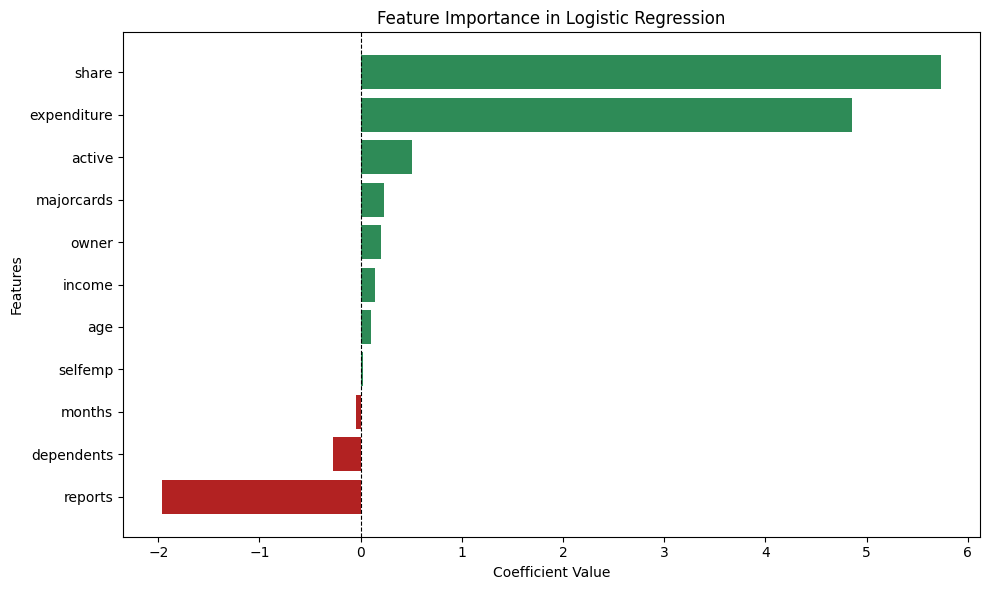

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ["seagreen" if val > 0 else "firebrick" for val in importance_df["Importance"]]

plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

**Which variables positively influence credit card approval?**

Variables with positive coefficients increase the predicted probability of approval: share (+5.73), expenditure (+4.85), active (+0.50), majorcards (+0.23), owner (+0.20), income (+0.15), age (+0.10), selfemp (+0.02).

**Which variables negatively influence credit card approval?**

Variables with negative coefficients decrease the probability of approval: reports (-1.96), dependents (-0.28), months (-0.05).

**Conclusions about variable importance:**

The two most influential features are **share** (ratio of monthly credit card expenses to annual income) and **expenditure** (average monthly credit card expenses), both strongly positive. This suggests that clients who actively spend on credit cards are actually more likely to be approved - likely because they are already experienced credit users with demonstrated repayment history.

The strongest negative predictor is **reports** (number of negative credit histories), which makes intuitive sense: a poor credit history is the clearest signal of credit risk and significantly reduces approval chances.

**dependents** also has a moderate negative effect, likely because more financial dependents increase the risk of default. **months** at the current address has a very small negative coefficient, which is counterintuitive (longer residence might suggest stability), but its effect is negligible.

Features like **selfemp, age, and owner** have small positive effects, suggesting they contribute modestly to approval but are not decisive factors on their own.

#**Model Evaluation**

**1. Make class predictions for the test data and evaluate the model accuracy using the accuracy metric.**

In [12]:
from sklearn import metrics

In [13]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9545454545454546


**2. Look at the ratio of classes 0 and 1 in the target variable.** Is it appropriate to use accuracy for this task? Justify your answer.

In [14]:
df["card"].value_counts(normalize=True)

,proportion
card,
1,0.775588
0,0.224412


The dataset is imbalanced — class 1 ("approved") makes up approximately 78% of all observations, while class 0 ("rejected") accounts for only 22%. In such cases, accuracy is not the most reliable metric, because a naive model that always predicts class 1 would already achieve ~78% accuracy without learning anything meaningful. Therefore, accuracy alone can be misleading here, and metrics like precision, recall, and F1-score are more informative for evaluating true model performance.

**3. Calculate other classification metrics for your model:** precision, recall, F1-score, specificity. Which one deserves more attention when evaluating model quality given the business context of the task? Draw conclusions.

In [15]:
from sklearn.metrics import confusion_matrix

# calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# calculate tp, tn, fp, fn
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

# calculate specificity
specificity = tn / (tn + fp)

# print results
print(confusion_matrix(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 score:", metrics.f1_score(y_test, y_pred))
print("Specificity:", specificity)


[[ 64   8]
 [  7 251]]
Precision: 0.9691119691119691
Recall: 0.9728682170542635
F1 score: 0.9709864603481625
Specificity: 0.8888888888888888


The model shows strong overall performance - **precision, recall, and F1-score** are all above **0.97**, meaning it correctly identifies approved applicants very well. However, **specificity** is noticeably lower at **0.889**, meaning the model incorrectly approves 8 out of 72 clients who should have been rejected (false positives).

**Which metric deserves the most attention?**

In the business context of credit card approval, specificity is the most critical metric.
- A **false positive** (predicting "approved" for a risky client) means the bank issues a credit card to someone likely to default - this results in a direct financial loss.
- A **false negative** (predicting "rejected" for a good client) means the bank misses a potential customer - this is an opportunity cost, but far less damaging.

The asymmetry of these errors makes specificity the priority: the cost of approving a bad client significantly outweighs the cost of rejecting a good one.


**4. Based on the "most problematic" metric, select optimal hyperparameters for the model.** Build validation curves. Use the following hyperparameters for optimization:
- penalty — the type of regularization or its absence;
- C — the inverse regularization strength.

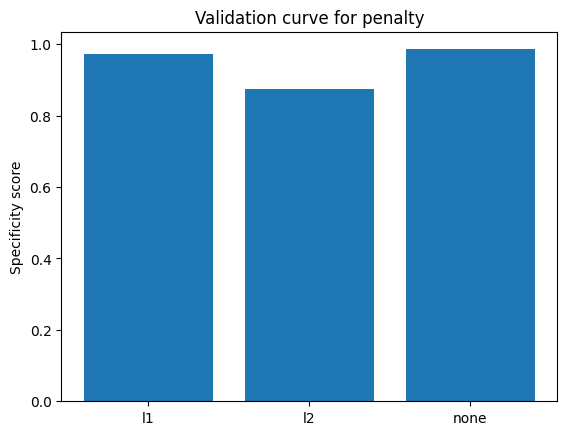

In [16]:
# iterate on penalty and calculate specificity
possible_penalties = ["l1", "l2", None]
penalty_labels = ["l1", "l2", "none"]
solvers = ["liblinear", "liblinear", "lbfgs"]
specificity_penalty = []

for penalty, solver in  zip(possible_penalties, solvers):
    model = LogisticRegression(penalty=penalty, C=1, solver=solver)
    model.fit(X_train_scaled, y_train)
    y_pred_p = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred_p)
    tn, fp = cm[0, 0], cm[0, 1]
    specificity_penalty.append(tn / (tn + fp))

# plot validation curve for penalty
plt.bar(penalty_labels, specificity_penalty)
plt.ylabel("Specificity score")
plt.title("Validation curve for penalty")
plt.show()

In [17]:
best_penalty = possible_penalties[specificity_penalty.index(max(specificity_penalty))]

print("Best penalty:", best_penalty)
print("Specificity scores:", specificity_penalty)

Best penalty: None
Specificity scores: [np.float64(0.9722222222222222), np.float64(0.875), np.float64(0.9861111111111112)]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and

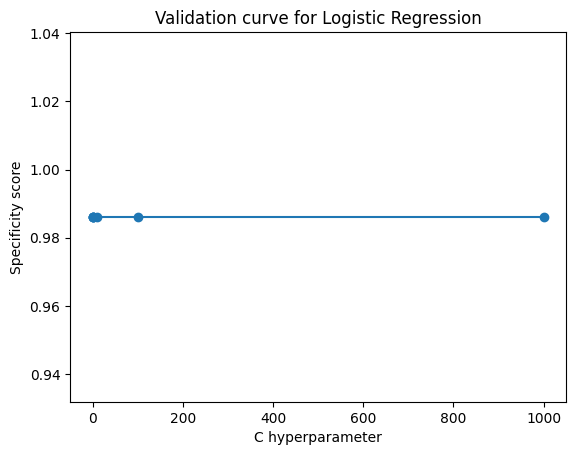

In [18]:
# iterate on C and calculate specificity
possible_C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
specificity_scores = []
for C in possible_C:
    model = LogisticRegression(C=C, penalty=None)
    model.fit(X_train_scaled, y_train)
    y_pred_c = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred_c)
    tn, fp = cm[0, 0], cm[0, 1]
    specificity_scores.append(tn / (tn + fp))

# plot validation curve for C
plt.plot(possible_C, specificity_scores, marker="o")
plt.xlabel("C hyperparameter")
plt.ylabel("Specificity score")
plt.title("Validation curve for Logistic Regression")
plt.show()

In [19]:
print("C values:", possible_C)
print("Specificity scores:", specificity_scores)

C values: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
Specificity scores: [np.float64(0.9861111111111112), np.float64(0.9861111111111112), np.float64(0.9861111111111112), np.float64(0.9861111111111112), np.float64(0.9861111111111112), np.float64(0.9861111111111112), np.float64(0.9861111111111112)]


**C Hyperparameter**

The specificity score is identical across all tested values of C (0.001-1000).

This is expected because the model uses **penalty=None**, meaning that no regularization is applied. In this configuration, the C parameter is not used in the optimization and therefore has no effect on the model.
Therefore, there is no single optimal value of C for this model - all tested values produce the same result. The flat validation curve reflects the fact that C is irrelevant when penalty=None.

**5. Evaluate the quality of the optimal model using all metrics.** Draw conclusions.

In [20]:
# build optimal model
model_optimized = LogisticRegression(penalty=None, solver="lbfgs")
model_optimized.fit(X_train_scaled, y_train)
y_pred_opt = model_optimized.predict(X_test_scaled)

# evaluate all metrics
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn = cm_opt[0, 0]
tp = cm_opt[1, 1]
fn = cm_opt[1, 0]
fp = cm_opt[0, 1]

specificity_opt = tn / (tn + fp)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred_opt))
print("Precision:", metrics.precision_score(y_test, y_pred_opt))
print("Recall:", metrics.recall_score(y_test, y_pred_opt))
print("F1-score:", metrics.f1_score(y_test, y_pred_opt))
print("Specificity:", specificity_opt)

Accuracy: 0.9727272727272728
Precision: 0.9960159362549801
Recall: 0.9689922480620154
F1-score: 0.9823182711198428
Specificity: 0.9861111111111112


The most significant improvement is in **specificity**. The optimized model now correctly rejects 71 out of 72 high-risk applicants, compared to only 64 out of 72 in the baseline. This means the number of false positives dropped from 8 to just 1, directly reducing the bank's financial exposure from issuing credit cards to clients likely to default.

**Precision** also improved notably (0.969 → 0.996), meaning nearly all clients predicted as creditworthy truly are. Recall and accuracy remained essentially unchanged, confirming that the improvement in specificity came without sacrificing the model's ability to approve genuinely good applicants.

The key insight is that removing regularization (penalty=None) was sufficient to achieve this improvement — the dataset is large and clean enough that constraining the model's weights was doing more harm than good.